In [846]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [847]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df = df.drop(columns=['OperatingSystems', 'Browser', 'Region', 'Weekend'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  TrafficType              12330 non-null  int64  
 12  VisitorType              12330 non-null  str    
 13  Revenue                  12330 non-null  bool   
dtypes: bool(1), float64(7), int64(4),

In [848]:
df.shape

(12330, 14)

In [849]:
df = df[~((df['Administrative'] + df['Informational'] + df['ProductRelated']) == 0)]
df.shape

(12324, 14)

In [850]:
df = df.sort_values('ProductRelated_Duration', ascending=False).reset_index(drop=True)
df.head(6)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,TrafficType,VisitorType,Revenue
0,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,0.0,Dec,2,Returning_Visitor,False
1,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,0.0,May,14,Returning_Visitor,False
2,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,0.0,Dec,2,Returning_Visitor,False
3,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,2,Returning_Visitor,True
4,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,8,Returning_Visitor,False
5,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,Sep,13,Returning_Visitor,False


In [851]:
df = df.drop(df.index[0:3]).reset_index(drop=True)
df.head(6)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,TrafficType,VisitorType,Revenue
0,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,2,Returning_Visitor,True
1,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,8,Returning_Visitor,False
2,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,Sep,13,Returning_Visitor,False
3,20,199.456273,7,299.033333,686,23342.08205,0.009853,0.022771,0.150650,0.0,Aug,1,Returning_Visitor,False
4,10,2407.423810,3,434.300000,486,23050.10414,0.000324,0.011249,0.000000,0.0,Jul,3,Returning_Visitor,False
5,12,245.733333,4,1511.700000,439,21857.04648,0.003589,0.012498,11.439233,0.0,Sep,13,Returning_Visitor,False


In [852]:
df.shape

(12321, 14)

In [853]:
# Drop Traffic Types with session counts less than 100, and one hot encode the rest
threshold = 100
traffic_count= df['TrafficType'].value_counts()
len(traffic_count)


20

In [854]:
kept_traffic = traffic_count[traffic_count > threshold].index
len(kept_traffic)

11

In [855]:
kept_traffic

Index([2, 1, 3, 4, 13, 10, 6, 8, 5, 11, 20], dtype='int64', name='TrafficType')

In [856]:
type(kept_traffic)

pandas.Index

In [857]:
df['TrafficType'] = df['TrafficType'].where(df['TrafficType'].isin(kept_traffic), 'Other')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,TrafficType,VisitorType,Revenue
0,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,2,Returning_Visitor,True
1,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,8,Returning_Visitor,False
2,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,Sep,13,Returning_Visitor,False
3,20,199.456273,7,299.033333,686,23342.08205,0.009853,0.022771,0.150650,0.0,Aug,1,Returning_Visitor,False
4,10,2407.423810,3,434.300000,486,23050.10414,0.000324,0.011249,0.000000,0.0,Jul,3,Returning_Visitor,False


In [858]:
df_encoded = pd.get_dummies(df, columns=['TrafficType'], drop_first=True)
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'VisitorType', 'Revenue', 'TrafficType_2', 'TrafficType_3',
       'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_8',
       'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_20',
       'TrafficType_Other'],
      dtype='str')


The bool column for TrafficType 1 was dropped.

In [859]:
df_encoded.shape

(12321, 24)

In [860]:
df['Month'].unique()

<StringArray>
['Nov', 'Sep', 'Aug', 'Jul', 'June', 'Dec', 'May', 'Mar', 'Oct', 'Feb']
Length: 10, dtype: str

In [861]:
df_encoded = pd.get_dummies(df_encoded, columns=['Month'], drop_first=True)
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'VisitorType',
       'Revenue', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_8', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_13', 'TrafficType_20',
       'TrafficType_Other', 'Month_Dec', 'Month_Feb', 'Month_Jul',
       'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct',
       'Month_Sep'],
      dtype='str')


In [862]:
df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_Other,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,...,False,False,False,False,False,False,False,True,False,False
1,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,...,False,False,False,False,False,False,False,True,False,False
2,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,...,False,False,False,False,False,False,False,False,False,True
3,20,199.456273,7,299.033333,686,23342.08205,0.009853,0.022771,0.150650,0.0,...,False,False,False,False,False,False,False,False,False,False
4,10,2407.423810,3,434.300000,486,23050.10414,0.000324,0.011249,0.000000,0.0,...,False,False,False,True,False,False,False,False,False,False


The August month bool variable was dropped.

In [863]:
df_encoded.shape

(12321, 32)

In [864]:
df_encoded = pd.get_dummies(df_encoded, columns=['VisitorType'])
df_encoded = df_encoded.drop(columns=['VisitorType_Other']) # Drop a column after creating to keep New_Visitor for it's coefficient
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue',
       'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
       'TrafficType_6', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11',
       'TrafficType_13', 'TrafficType_20', 'TrafficType_Other', 'Month_Dec',
       'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May',
       'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor',
       'VisitorType_Returning_Visitor'],
      dtype='str')


In [865]:
cols_skew_check = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

for col in cols_skew_check:
    print(f'{col}:, {df_encoded[col].skew()}')

Administrative_Duration:, 5.062984001345574
Informational_Duration:, 7.303249374031861
ProductRelated_Duration:, 4.14772839767116
BounceRates:, 2.957076356738261
ExitRates:, 2.152712350259609
PageValues:, 6.380656779892499


In [866]:
print("New Skews")

for col in cols_skew_check:
    df_encoded[f'{col}_log'] = np.log1p(df_encoded[col])
    print(f'{col}_log:, {df_encoded[f'{col}_log'].skew()}')

New Skews
Administrative_Duration_log:, 0.25334037747630644
Informational_Duration_log:, 1.9173473578473292
ProductRelated_Duration_log:, -1.4256777591959868
BounceRates_log:, 2.886209181596003
ExitRates_log:, 2.058557508240496
PageValues_log:, 1.8048083693877786


Administrative_Duration did well under a log transform.
Informational_Duration needs further inspection due to an insufficient decrease in skew (above 1).
ProductRelated_Duration went into a negative skew, likely due to the extreme outliers, which will likely need to be handled.
BounceRates and ExitRates showed a negligable change after log transform, and should be inspected.
PageValues decreased significantly, but needs to be further inspected (still above 1).

## Investigate Informational_Duration

In [867]:
(df_encoded['Informational_Duration'] == 0).mean()

np.float64(0.805048291534778)

<Axes: >

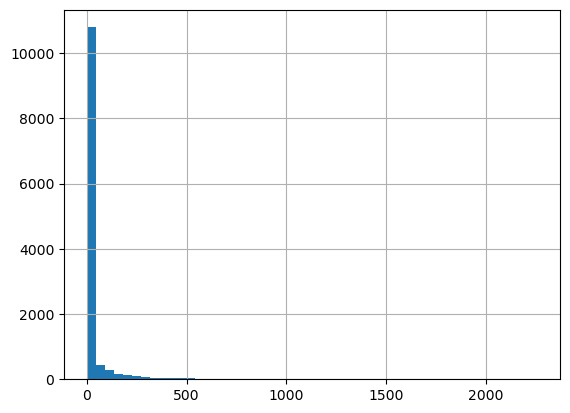

In [868]:
df_encoded['Informational_Duration'].hist(bins=50)

Informational_Duration has 0 values for 80% of the sessions, with which log transform did not sufficiently help.

Create an additional column to inform the model on whether informational pages were visited, keeping Informational_Duration to measure the effect of time.

In [869]:
df_encoded['Visited_Informational'] = (df_encoded['Informational_Duration'] > 0).astype(int)

## Investigate ProductRelated_Duration

In [870]:
df_encoded['ProductRelated_Duration'].describe()

count    12321.000000
mean      1184.490356
std       1770.274481
min          0.000000
25%        184.500000
50%        599.000000
75%       1464.000000
max      27009.859430
Name: ProductRelated_Duration, dtype: float64

Extreme outliers are affecting the impact of a log transform.

In [871]:
# Check where the extremes are
df_encoded['ProductRelated_Duration'].quantile([.9, .95, .99, .999])

0.900     2875.615909
0.950     4293.400000
0.990     8649.239017
0.999    15888.870741
Name: ProductRelated_Duration, dtype: float64

The duration approximately doubles as the quantile increases between the chosen values- there is no one extreme outlier to remove.

In [872]:
df_encoded['ProductRelated_Duration'].sort_values(ascending=False).head(10)

0    27009.85943
1    24844.15620
2    23888.81000
3    23342.08205
4    23050.10414
5    21857.04648
6    21672.24425
7    18504.12621
8    18171.79454
9    17550.58486
Name: ProductRelated_Duration, dtype: float64

In [873]:
# The originally log transformed duration
df_encoded['ProductRelated_Duration_log'].skew()

np.float64(-1.4256777591959868)

In [874]:
# Try capping to the value at the 99.9th quantile, minimizing the affect to only 0.1% of the data
cap_value = df_encoded['ProductRelated_Duration'].quantile(.999)
df_encoded['ProductRelated_Duration_caped'] = df_encoded['ProductRelated_Duration'].clip(upper=cap_value)
df_encoded['ProductRelated_Duration_caped_log'] = np.log1p(df_encoded['ProductRelated_Duration_caped'])
df_encoded['ProductRelated_Duration_caped_log'].skew()

np.float64(-1.4277704254276313)

In [875]:
cap_value = df_encoded['ProductRelated_Duration'].quantile(.99)
df_encoded['ProductRelated_Duration_caped'] = df_encoded['ProductRelated_Duration'].clip(upper=cap_value)
df_encoded['ProductRelated_Duration_caped_log'] = np.log1p(df_encoded['ProductRelated_Duration_caped'])
df_encoded['ProductRelated_Duration_caped_log'].skew()

np.float64(-1.4433176257124105)

Capping before log transforming did not fix the skew, meaning the over correction during log transform isnt coming from the extreme outliers.

In [876]:
# Check the low end distribution instead
df_encoded['ProductRelated_Duration'].quantile([.01, .05, .10, .25])

0.01      0.0
0.05      0.0
0.10     36.0
0.25    184.5
Name: ProductRelated_Duration, dtype: float64

While the outliers reach 27k seconds, 25% of the sessions have durations 184 or under, with 5% of sessions at 0.

In [877]:
(df_encoded['ProductRelated_Duration'] == 0).mean()

np.float64(0.06079052024997971)

<Axes: >

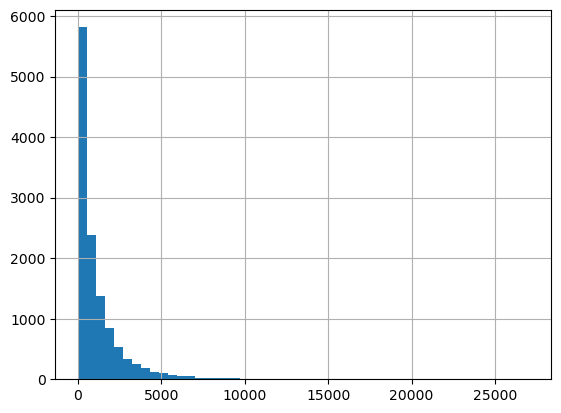

In [878]:
df_encoded['ProductRelated_Duration'].hist(bins=50)

In [879]:
# Try sqrt instead of log1p
df_encoded['ProductRelated_Duration_sqrt'] = np.sqrt(df_encoded['ProductRelated_Duration'])
print(df_encoded['ProductRelated_Duration_sqrt'].skew())

1.242341787132512


The sqrt transormation more gently adjusted the feature's skew from approximately 4.15 to 1.24, instead of the log transformed skew, attempted with and without capping- resulting in an over corrected skew around -1.4.

<Axes: >

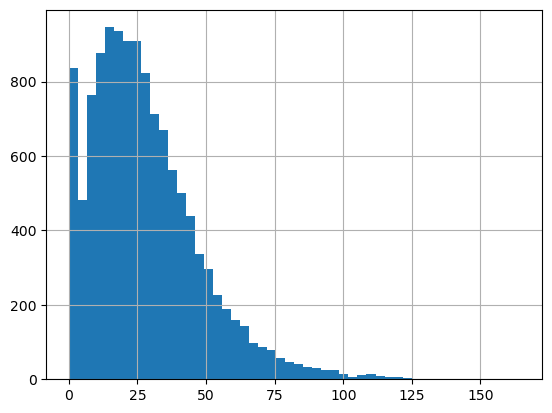

In [880]:
df_encoded['ProductRelated_Duration_sqrt'].hist(bins=50)

In [881]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12321 entries, 0 to 12320
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Administrative                     12321 non-null  int64  
 1   Administrative_Duration            12321 non-null  float64
 2   Informational                      12321 non-null  int64  
 3   Informational_Duration             12321 non-null  float64
 4   ProductRelated                     12321 non-null  int64  
 5   ProductRelated_Duration            12321 non-null  float64
 6   BounceRates                        12321 non-null  float64
 7   ExitRates                          12321 non-null  float64
 8   PageValues                         12321 non-null  float64
 9   SpecialDay                         12321 non-null  float64
 10  Revenue                            12321 non-null  bool   
 11  TrafficType_2                      12321 non-null  bool   
 12  T

In [ ]:
df_encoded = df_encoded.drop(columns=[
    'ProductRelated_Duration_caped', 
    'ProductRelated_Duration_caped_log', 
    'ProductRelated_Duration', 
    'ProductRelated_Duration_log', 
    'Administrative_Duration', 
    'Informational_Duration'
    ])
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12321 entries, 0 to 12320
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12321 non-null  int64  
 1   Informational                  12321 non-null  int64  
 2   ProductRelated                 12321 non-null  int64  
 3   BounceRates                    12321 non-null  float64
 4   ExitRates                      12321 non-null  float64
 5   PageValues                     12321 non-null  float64
 6   SpecialDay                     12321 non-null  float64
 7   Revenue                        12321 non-null  bool   
 8   TrafficType_2                  12321 non-null  bool   
 9   TrafficType_3                  12321 non-null  bool   
 10  TrafficType_4                  12321 non-null  bool   
 11  TrafficType_5                  12321 non-null  bool   
 12  TrafficType_6                  12321 non-null  bool   
 1